<a href="https://colab.research.google.com/github/ManyaGupta23/Student_Prediction_System/blob/main/Student_prediction_system_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Uploading Excel File**

In [2]:
from google.colab import files
uploaded = files.upload()

Saving student_performance.xlsx to student_performance.xlsx


# **Importing Libraries**

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier



#*Load Data*

In [8]:
df= pd.read_excel("student_performance.xlsx", sheet_name="Students_Data")

print("Data loaded")
print(df.head())

Data loaded
   Student_ID   Name  ...  Final_Result  Performance_Index
0         101  Rahul  ...             A               80.7
1         102  Priya  ...             C               54.5
2         103   Aman  ...             A               87.7
3         104  Sneha  ...             B               65.0
4         105  Rohit  ...          Fail               45.0

[5 rows x 10 columns]


#*Preprocessing*

In [9]:
df['Extra_Activities'] = df['Extra_Activities'].map({'Yes': 1, 'No': 0})
df['Final_Result'] = df['Final_Result'].map({'A': 3, 'B': 2, 'C': 1, 'Fail': 0})

df = df.fillna(0)

#**Feature & Targets**

In [10]:

X = df[['Attendence','Study_Hours', 'Internal_Marks', 'Assignment_Score', 'Extra_Activities']]
y = df['Final_Result']

#**Train-Test Split**

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#**Model Camparision**

In [20]:

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

print("\nModel Accuracy 🔥")
for m, acc in results.items():
    print(f"{m}: {acc}")

# Best Model
best_model_name = max(results, key=results.get)
print("\nBest Model:", best_model_name)

best_model = models[best_model_name]


Model Accuracy 🔥
Logistic Regression: 1.0
Decision Tree: 1.0
Random Forest: 1.0

Best Model: Logistic Regression


#**Visualzation**

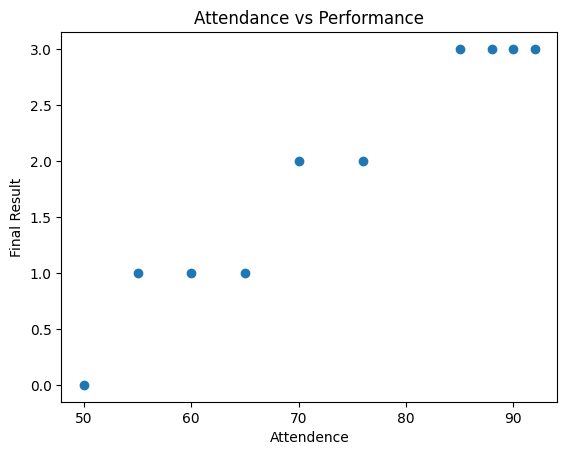

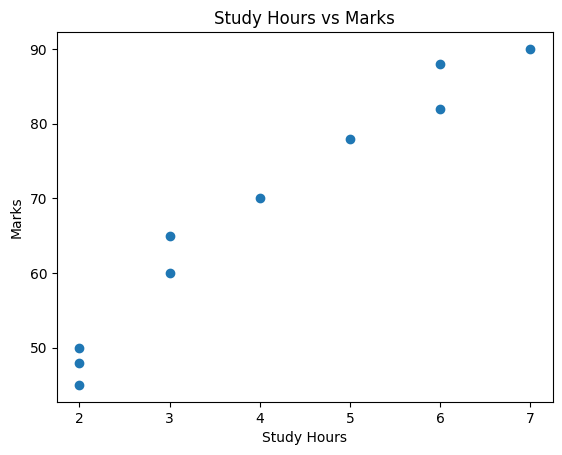

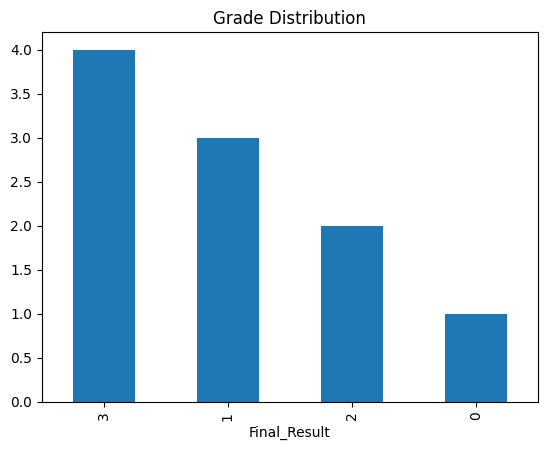

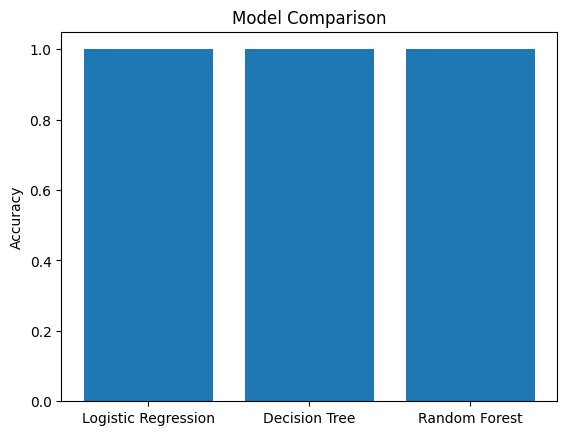

In [14]:
# Graph 1
plt.scatter(df['Attendence'], df['Final_Result'])
plt.xlabel("Attendence")
plt.ylabel("Final Result")
plt.title("Attendance vs Performance")
plt.show()

# Graph 2
plt.scatter(df['Study_Hours'], df['Internal_Marks'])
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Study Hours vs Marks")
plt.show()

# Graph 3
df['Final_Result'].value_counts().plot(kind='bar')
plt.title("Grade Distribution")
plt.show()

# Model Comparison Graph
plt.bar(results.keys(), results.values())
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

#**Prediction Function**

In [15]:
def predict_student(attendence, study_hours, internal_marks, assignment_score, extra_activities):

    extra = 1 if extra_activities.lower() == "yes" else 0

    data = [[attendence, study_hours, internal_marks, assignment_score, extra]]

    pred = best_model.predict(data)[0]

    grade_map = {3: 'A', 2: 'B', 1: 'C', 0: 'Fail'}
    grade = grade_map[pred]

    if pred == 0:
        risk = "High"
        suggestion = "Immediate improvement needed"
    elif pred == 1:
        risk = "Medium"
        suggestion = "Increase study hours"
    else:
        risk = "Low"
        suggestion = "Good performance"

    return grade, risk, suggestion


#**Test Predicton**

In [16]:
def predict_student(Attendence, Study_Hours, Internal_Marks, Assignment_Score, Extra_Activities):

    extra = 1 if Extra_Activities.lower() == "yes" else 0

    import pandas as pd
    data = pd.DataFrame([[Attendence, Study_Hours, Internal_Marks, Assignment_Score, Extra_Activities]],
                        columns=['Attendance', 'Study_Hours', 'Internal_Marks', 'Assignment_Score', 'Extra_Activities'])

    pred = best_model.predict(data)[0]

    grade_map = {3: 'A', 2: 'B', 1: 'C', 0: 'Fail'}
    grade = grade_map[pred]

    if pred == 0:
        risk = "High"
        suggestion = "Immediate improvement needed"
    elif pred == 1:
        risk = "Medium"
        suggestion = "Increase study hours"
    else:
        risk = "Low"
        suggestion = "Good performance"

    return grade, risk, suggestion

#**Confusion Matrix**

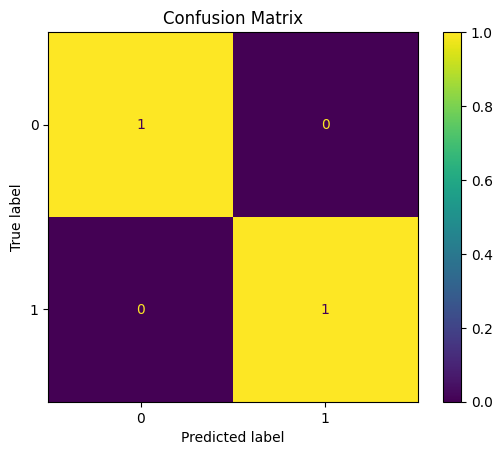

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()